# education analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression, LassoCV, RidgeCV
from sklearn.inspection import permutation_importance

try:
    from xgboost import XGBRegressor, XGBClassifier
    xgb_available = True
except:
    xgb_available = False

In [2]:
file_path = "SPSS_data.xlsx"
df = pd.read_excel(file_path)
df.columns = df.columns.str.strip()
df.head()

,ID,PS-Q1,PS-Q2,PS-Q3,PS-Q4,PS-Q5,PS-Q6,PS-Q7,PS-Q8,PS-Q9,...,PCR-Q21,PCR-Q22,PCR-Q23,PCR-Q24,PCR-Q25,PCR-Q26,PCR-Q27,PCR-Q28,PCR-Q29,PCR-Q30
0,1,5,5,5,5,5,5,5,5,5,...,1,5,1,5,5,5,1,1,5,5
1,2,4,4,4,4,4,4,4,4,4,...,1,5,1,1,5,5,1,3,5,5
2,3,5,5,5,5,5,5,5,5,5,...,2,2,3,3,2,4,3,4,4,4
3,4,4,4,4,4,4,4,4,5,5,...,2,4,1,1,1,5,3,4,4,5
4,5,5,5,5,5,5,5,4,5,5,...,5,5,5,5,5,5,5,5,5,5


In [3]:
ps_items = [f"PS-Q{i}" for i in range(1, 25)]
pcr_items = [f"PCR-Q{i}" for i in range(1, 31)]

ps_reverse = [f"PS-Q{i}" for i in range(16, 25)]
pcr_reverse = ["PCR-Q2","PCR-Q4","PCR-Q6","PCR-Q7","PCR-Q12","PCR-Q14","PCR-Q17","PCR-Q19","PCR-Q21","PCR-Q23","PCR-Q24","PCR-Q25"]

In [4]:
df2 = df.copy()

for col in ps_reverse:
    df2[col] = 6 - df2[col]

for col in pcr_reverse:
    df2[col] = 6 - df2[col]

df2.head()

,ID,PS-Q1,PS-Q2,PS-Q3,PS-Q4,PS-Q5,PS-Q6,PS-Q7,PS-Q8,PS-Q9,...,PCR-Q21,PCR-Q22,PCR-Q23,PCR-Q24,PCR-Q25,PCR-Q26,PCR-Q27,PCR-Q28,PCR-Q29,PCR-Q30
0,1,5,5,5,5,5,5,5,5,5,...,5,5,5,1,1,5,1,1,5,5
1,2,4,4,4,4,4,4,4,4,4,...,5,5,5,5,1,5,1,3,5,5
2,3,5,5,5,5,5,5,5,5,5,...,4,2,3,3,4,4,3,4,4,4
3,4,4,4,4,4,4,4,4,5,5,...,4,4,5,5,5,5,3,4,4,5
4,5,5,5,5,5,5,5,4,5,5,...,1,5,1,1,1,5,5,5,5,5


In [5]:
df2["PS_score"] = df2[ps_items].mean(axis=1)
df2["PCR_score"] = df2[pcr_items].mean(axis=1)

df2[["PS_score", "PCR_score"]].describe()

,PS_score,PCR_score
count,506.000000,506.000000
mean,3.341238,3.266206
std,1.014027,0.779039
min,1.208333,1.300000
25%,2.583333,2.733333
50%,3.541667,3.433333
75%,4.166667,3.900000
max,5.000000,4.533333


In [6]:
def cronbach_alpha(df_items):
    df_items = df_items.dropna()
    k = df_items.shape[1]
    item_var = df_items.var(axis=0, ddof=1).sum()
    total_var = df_items.sum(axis=1).var(ddof=1)
    return (k / (k - 1)) * (1 - item_var / total_var)

alpha_ps = cronbach_alpha(df2[ps_items])
alpha_pcr = cronbach_alpha(df2[pcr_items])

pd.DataFrame({
    "Scale": ["Parenting Style", "Parent-Child Relationship"],
    "Cronbach_alpha": [alpha_ps, alpha_pcr]
})

,Scale,Cronbach_alpha
0,Parenting Style,0.975133
1,Parent-Child Relationship,0.940411


In [7]:
ps_complete = df2[ps_items].dropna()
pcr_complete = df2[pcr_items].dropna()

scaler_ps = StandardScaler()
ps_z = scaler_ps.fit_transform(ps_complete)

scaler_pcr = StandardScaler()
pcr_z = scaler_pcr.fit_transform(pcr_complete)

In [8]:
pca_ps = PCA(n_components=3)
ps_scores = pca_ps.fit_transform(ps_z)

ps_loadings = pd.DataFrame(
    pca_ps.components_.T,
    index=ps_items,
    columns=["PS_authoritative", "PS_authoritarian", "PS_permissive"]
)

ps_var = pd.DataFrame({
    "Eigenvalue": pca_ps.explained_variance_,
    "Variance_%": pca_ps.explained_variance_ratio_ * 100,
    "Cumulative_%": np.cumsum(pca_ps.explained_variance_ratio_ * 100)
}, index=["PS_authoritative", "PS_authoritarian", "PS_permissive"])

ps_var

,Eigenvalue,Variance_%,Cumulative_%
PS_authoritative,15.343751,63.805945,63.805945
PS_authoritarian,1.966335,8.176872,71.982817
PS_permissive,0.523443,2.176703,74.159520


In [9]:
ps_loadings

,PS_authoritative,PS_authoritarian,PS_permissive
PS-Q1,-0.210939,-0.108601,-0.159479
PS-Q2,-0.214810,-0.152560,-0.132539
PS-Q3,-0.215955,-0.163432,0.073950
PS-Q4,-0.214047,-0.159300,-0.037182
PS-Q5,-0.210608,-0.127162,-0.164135
PS-Q6,-0.213233,-0.105317,-0.230517
PS-Q7,-0.199822,-0.125378,-0.346852
PS-Q8,-0.217112,-0.133933,0.157442
PS-Q9,-0.215511,-0.138091,0.186178
PS-Q10,-0.219483,-0.152464,0.146557


In [10]:
pca_pcr = PCA(n_components=3)
pcr_scores = pca_pcr.fit_transform(pcr_z)

pcr_loadings = pd.DataFrame(
    pca_pcr.components_.T,
    index=pcr_items,
    columns=["PCR_closeness", "PCR_dependency", "PCR_conflict"]
)

pcr_var = pd.DataFrame({
    "Eigenvalue": pca_pcr.explained_variance_,
    "Variance_%": pca_pcr.explained_variance_ratio_ * 100,
    "Cumulative_%": np.cumsum(pca_pcr.explained_variance_ratio_ * 100)
}, index=["PCR_closeness", "PCR_dependency", "PCR_conflict"])

pcr_var

,Eigenvalue,Variance_%,Cumulative_%
PCR_closeness,15.382622,51.174073,51.174073
PCR_dependency,3.040225,10.114056,61.288129
PCR_conflict,1.467204,4.881016,66.169145


In [11]:
pcr_loadings

,PCR_closeness,PCR_dependency,PCR_conflict
PCR-Q1,-0.195498,-0.074292,-0.211289
PCR-Q2,-0.188396,-0.227033,0.134825
PCR-Q3,-0.198519,-0.003507,-0.180834
PCR-Q4,-0.174369,-0.212825,0.115811
PCR-Q5,-0.203826,-0.077578,-0.254076
PCR-Q6,-0.164364,-0.185225,0.288626
PCR-Q7,-0.186458,-0.189314,0.143937
PCR-Q8,-0.202566,-0.050921,-0.279481
PCR-Q9,-0.172231,0.196269,0.043451
PCR-Q10,-0.209976,-0.021212,-0.248445


In [12]:
complete_index = df2[ps_items + pcr_items].dropna().index

analysis_df = df2.loc[complete_index].copy()

analysis_df["PS_authoritative"] = ps_scores[:, 0]
analysis_df["PS_authoritarian"] = ps_scores[:, 1]
analysis_df["PS_permissive"] = ps_scores[:, 2]

analysis_df["PCR_closeness"] = pcr_scores[:, 0]
analysis_df["PCR_dependency"] = pcr_scores[:, 1]
analysis_df["PCR_conflict"] = pcr_scores[:, 2]

analysis_df[[
    "PS_authoritative", "PS_authoritarian", "PS_permissive",
    "PCR_closeness", "PCR_dependency", "PCR_conflict"
]].head()

,PS_authoritative,PS_authoritarian,PS_permissive,PCR_closeness,PCR_dependency,PCR_conflict
0,-5.210509,-1.332293,-2.296887,-0.502390,-3.027163,-3.638766
1,-2.991102,0.997876,-1.207622,-2.270679,-5.228468,-2.083236
2,-6.363177,0.790398,-0.217902,-1.559303,-1.674857,0.050986
3,0.174041,-6.281860,0.302173,-2.396264,-2.112511,-0.423531
4,-6.029102,1.019297,-0.010075,-2.369502,6.558064,-4.195263


In [13]:
analysis_df[[
    "PS_authoritative", "PS_authoritarian", "PS_permissive",
    "PCR_closeness", "PCR_dependency", "PCR_conflict"
]].describe().T

,count,mean,std,min,25%,50%,75%,max
PS_authoritative,506.0,2.246775e-16,3.917110,-6.363177,-3.122601,-0.781401,2.923813,8.211826
PS_authoritarian,506.0,4.212704e-17,1.402261,-7.022855,-0.448135,0.150479,0.753159,7.515623
PS_permissive,506.0,2.808469e-17,0.723494,-2.296887,-0.453213,0.003491,0.390601,2.524400
PCR_closeness,506.0,0.000000e+00,3.922069,-6.867790,-2.910787,-0.885859,2.445725,9.045696
PCR_dependency,506.0,1.404235e-16,1.743624,-5.635191,-0.668641,0.255560,0.930367,6.558064
PCR_conflict,506.0,-1.965929e-16,1.211282,-4.195263,-0.645226,0.051153,0.800722,5.245080


In [14]:
corr_df = analysis_df[[
    "PS_authoritative", "PS_authoritarian", "PS_permissive",
    "PCR_closeness", "PCR_dependency", "PCR_conflict"
]]

corr_mat = corr_df.corr()
corr_mat

,PS_authoritative,PS_authoritarian,PS_permissive,PCR_closeness,PCR_dependency,PCR_conflict
PS_authoritative,1.000000e+00,-1.406856e-17,-3.901022e-17,9.170788e-02,1.227425e-01,2.655333e-01
PS_authoritarian,-1.406856e-17,1.000000e+00,8.315794e-17,8.172548e-02,7.309216e-02,1.204998e-01
PS_permissive,-3.901022e-17,8.315794e-17,1.000000e+00,-1.049600e-01,-9.874425e-02,-8.251640e-02
PCR_closeness,9.170788e-02,8.172548e-02,-1.049600e-01,1.000000e+00,-8.409855e-17,-2.600726e-16
PCR_dependency,1.227425e-01,7.309216e-02,-9.874425e-02,-8.409855e-17,1.000000e+00,-4.598820e-16
PCR_conflict,2.655333e-01,1.204998e-01,-8.251640e-02,-2.600726e-16,-4.598820e-16,1.000000e+00


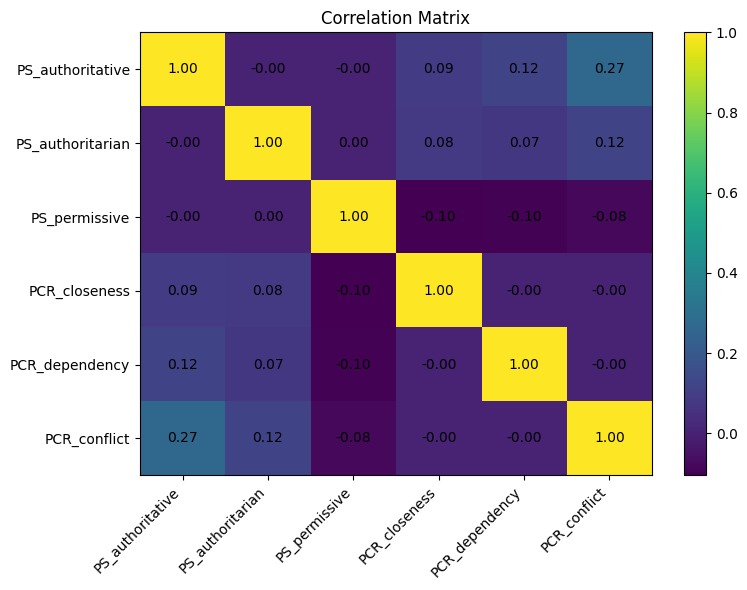

In [15]:
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr_mat, aspect="auto")
ax.set_xticks(range(len(corr_mat.columns)))
ax.set_xticklabels(corr_mat.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr_mat.index)))
ax.set_yticklabels(corr_mat.index)

for i in range(corr_mat.shape[0]):
    for j in range(corr_mat.shape[1]):
        ax.text(j, i, f"{corr_mat.iloc[i, j]:.2f}", ha="center", va="center")

plt.colorbar(im)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [16]:
def run_ols(y_name):
    X = analysis_df[["PS_authoritative", "PS_authoritarian", "PS_permissive"]]
    X = sm.add_constant(X)
    y = analysis_df[y_name]
    model = sm.OLS(y, X).fit()
    return model

model_closeness = run_ols("PCR_closeness")
model_dependency = run_ols("PCR_dependency")
model_conflict = run_ols("PCR_conflict")

In [17]:
print(model_closeness.summary())

                            OLS Regression Results                            
Dep. Variable:          PCR_closeness   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.020
Method:                 Least Squares   F-statistic:                     4.486
Date:                Thu, 19 Mar 2026   Prob (F-statistic):            0.00404
Time:                        10:43:40   Log-Likelihood:                -1402.3
No. Observations:                 506   AIC:                             2813.
Df Residuals:                     502   BIC:                             2830.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.175e-17      0.173  

In [18]:
print(model_dependency.summary())

                            OLS Regression Results                            
Dep. Variable:         PCR_dependency   R-squared:                       0.030
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     5.203
Date:                Thu, 19 Mar 2026   Prob (F-statistic):            0.00151
Time:                        10:43:40   Log-Likelihood:                -991.05
No. Observations:                 506   AIC:                             1990.
Df Residuals:                     502   BIC:                             2007.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const             8.441e-17      0.077  

In [19]:
print(model_conflict.summary())

                            OLS Regression Results                            
Dep. Variable:           PCR_conflict   R-squared:                       0.092
Model:                            OLS   Adj. R-squared:                  0.086
Method:                 Least Squares   F-statistic:                     16.92
Date:                Thu, 19 Mar 2026   Prob (F-statistic):           1.75e-10
Time:                        10:43:40   Log-Likelihood:                -790.10
No. Observations:                 506   AIC:                             1588.
Df Residuals:                     502   BIC:                             1605.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -1.546e-16      0.051  

In [20]:
def extract_ols_table(model, outcome):
    table = pd.DataFrame({
        "Outcome": outcome,
        "term": model.params.index,
        "coef": model.params.values,
        "p_value": model.pvalues.values,
        "t_value": model.tvalues.values
    })
    return table

ols_results = pd.concat([
    extract_ols_table(model_closeness, "Closeness"),
    extract_ols_table(model_dependency, "Dependency"),
    extract_ols_table(model_conflict, "Conflict")
], ignore_index=True)

ols_results

,Outcome,term,coef,p_value,t_value
0,Closeness,const,-3.174672e-17,1.000000e+00,-1.839540e-16
1,Closeness,PS_authoritative,9.182397e-02,3.783876e-02,2.082105e+00
2,Closeness,PS_authoritarian,2.285830e-01,6.411534e-02,1.855468e+00
3,Closeness,PS_permissive,-5.689895e-01,1.754435e-02,-2.382977e+00
4,Dependency,const,8.440669e-17,1.000000e+00,1.102440e-15
5,Dependency,PS_authoritative,5.463639e-02,5.429481e-03,2.792521e+00
6,Dependency,PS_authoritarian,9.088556e-02,9.695188e-02,1.662924e+00
7,Dependency,PS_permissive,-2.379742e-01,2.510359e-02,-2.246536e+00
8,Conflict,const,-1.546147e-16,1.000000e+00,-3.004036e-15
9,Conflict,PS_authoritative,8.211046e-02,9.149732e-10,6.242937e+00


In [21]:
analysis_std = analysis_df.copy()

std_cols = [
    "PS_authoritative", "PS_authoritarian", "PS_permissive",
    "PCR_closeness", "PCR_dependency", "PCR_conflict"
]

analysis_std[std_cols] = StandardScaler().fit_transform(analysis_std[std_cols])

def run_std_ols(y_name):
    X = analysis_std[["PS_authoritative", "PS_authoritarian", "PS_permissive"]]
    X = sm.add_constant(X)
    y = analysis_std[y_name]
    model = sm.OLS(y, X).fit()
    return model

std_closeness = run_std_ols("PCR_closeness")
std_dependency = run_std_ols("PCR_dependency")
std_conflict = run_std_ols("PCR_conflict")

In [22]:
std_results = pd.concat([
    extract_ols_table(std_closeness, "Closeness_std"),
    extract_ols_table(std_dependency, "Dependency_std"),
    extract_ols_table(std_conflict, "Conflict_std")
], ignore_index=True)

std_results

,Outcome,term,coef,p_value,t_value
0,Closeness_std,const,-2.972695e-17,1.000000e+00,-6.749107e-16
1,Closeness_std,PS_authoritative,9.170788e-02,3.783876e-02,2.082105e+00
2,Closeness_std,PS_authoritarian,8.172548e-02,6.411534e-02,1.855468e+00
3,Closeness_std,PS_permissive,-1.049600e-01,1.754435e-02,-2.382977e+00
4,Dependency_std,const,-1.668455e-17,1.000000e+00,-3.795912e-16
5,Dependency_std,PS_authoritative,1.227425e-01,5.429481e-03,2.792521e+00
6,Dependency_std,PS_authoritarian,7.309216e-02,9.695188e-02,1.662924e+00
7,Dependency_std,PS_permissive,-9.874425e-02,2.510359e-02,-2.246536e+00
8,Conflict_std,const,1.860806e-17,1.000000e+00,4.374929e-16
9,Conflict_std,PS_authoritative,2.655333e-01,9.149732e-10,6.242937e+00


In [23]:
X1 = sm.add_constant(analysis_df["PS_authoritative"])
Y1 = analysis_df["PCR_closeness"]
med_step1 = sm.OLS(Y1, X1).fit()

M = analysis_df["PCR_dependency"]
med_step2 = sm.OLS(M, X1).fit()

X3 = sm.add_constant(analysis_df[["PS_authoritative", "PCR_dependency"]])
med_step3 = sm.OLS(Y1, X3).fit()

print(med_step1.summary())
print(med_step2.summary())
print(med_step3.summary())

                            OLS Regression Results                            
Dep. Variable:          PCR_closeness   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     4.275
Date:                Thu, 19 Mar 2026   Prob (F-statistic):             0.0392
Time:                        10:43:40   Log-Likelihood:                -1406.9
No. Observations:                 506   AIC:                             2818.
Df Residuals:                     504   BIC:                             2826.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
const            -3.175e-17      0.174  

In [24]:
a = med_step2.params["PS_authoritative"]
b = med_step3.params["PCR_dependency"]
c_prime = med_step3.params["PS_authoritative"]
c_total = med_step1.params["PS_authoritative"]

indirect = a * b
total = indirect + c_prime

pd.DataFrame({
    "Effect": ["a", "b", "Direct_c_prime", "Total_c", "Indirect_ab"],
    "Value": [a, b, c_prime, c_total, indirect]
})

,Effect,Value
0,a,0.054636
1,b,-0.025707
2,Direct_c_prime,0.093229
3,Total_c,0.091824
4,Indirect_ab,-0.001405


In [25]:
path_results = std_results[std_results["term"] != "const"].copy()
path_results

,Outcome,term,coef,p_value,t_value
1,Closeness_std,PS_authoritative,0.091708,3.783876e-02,2.082105
2,Closeness_std,PS_authoritarian,0.081725,6.411534e-02,1.855468
3,Closeness_std,PS_permissive,-0.104960,1.754435e-02,-2.382977
5,Dependency_std,PS_authoritative,0.122742,5.429481e-03,2.792521
6,Dependency_std,PS_authoritarian,0.073092,9.695188e-02,1.662924
7,Dependency_std,PS_permissive,-0.098744,2.510359e-02,-2.246536
9,Conflict_std,PS_authoritative,0.265533,9.149732e-10,6.242937
10,Conflict_std,PS_authoritarian,0.120500,4.795892e-03,2.833063
11,Conflict_std,PS_permissive,-0.082516,5.293474e-02,-1.940038


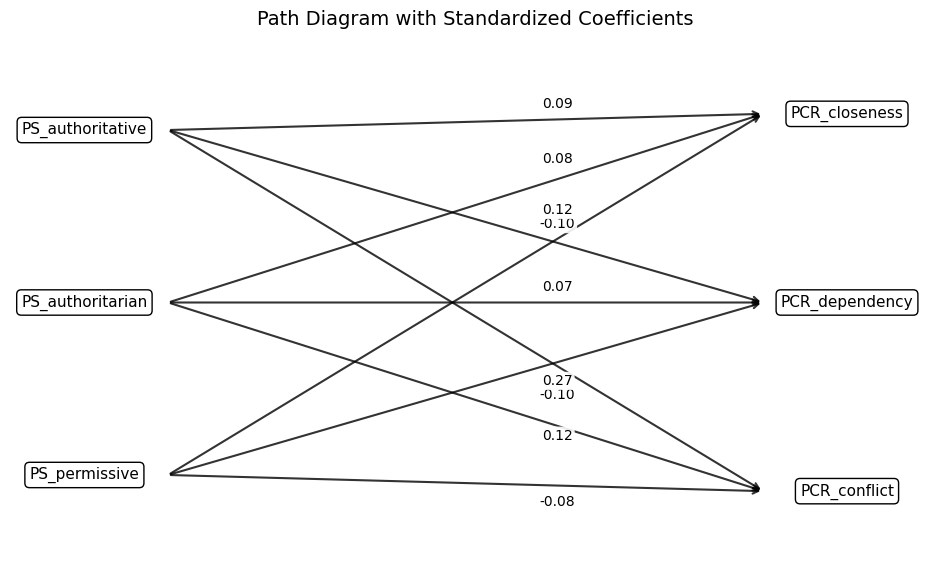

In [26]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 7))
ax.axis("off")

positions = {
    "PS_authoritative": (0.08, 0.82),
    "PS_authoritarian": (0.08, 0.50),
    "PS_permissive": (0.08, 0.18),
    "PCR_closeness": (0.90, 0.85),
    "PCR_dependency": (0.90, 0.50),
    "PCR_conflict": (0.90, 0.15)
}

for node, (x, y) in positions.items():
    ax.text(
        x, y, node,
        ha="center", va="center",
        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"),
        fontsize=11
    )

label_offsets = {
    ("PS_authoritative", "PCR_closeness"): 0.03,
    ("PS_authoritative", "PCR_dependency"): 0.05,
    ("PS_authoritative", "PCR_conflict"): -0.05,
    ("PS_authoritarian", "PCR_closeness"): 0.05,
    ("PS_authoritarian", "PCR_dependency"): 0.03,
    ("PS_authoritarian", "PCR_conflict"): -0.03,
    ("PS_permissive", "PCR_closeness"): 0.05,
    ("PS_permissive", "PCR_dependency"): -0.05,
    ("PS_permissive", "PCR_conflict"): -0.03
}

for _, row in path_results.iterrows():
    source = row["term"]

    if row["Outcome"].startswith("Closeness"):
        target = "PCR_closeness"
    elif row["Outcome"].startswith("Dependency"):
        target = "PCR_dependency"
    else:
        target = "PCR_conflict"

    x1, y1 = positions[source]
    x2, y2 = positions[target]

    ax.annotate(
        "",
        xy=(x2 - 0.09, y2),
        xytext=(x1 + 0.09, y1),
        arrowprops=dict(arrowstyle="->", lw=1.5, alpha=0.8)
    )

    mx = x1 + 0.62 * (x2 - x1)
    my = y1 + 0.62 * (y2 - y1)
    my += label_offsets[(source, target)]

    ax.text(
        mx, my,
        f"{row['coef']:.2f}",
        ha="center", va="center",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.15", fc="white", ec="none", alpha=0.9)
    )

plt.title("Path Diagram with Standardized Coefficients", fontsize=14)
plt.show()

In [27]:
X = analysis_df[["PS_authoritative", "PS_authoritarian", "PS_permissive"]]
y = analysis_df["PCR_closeness"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_reg = RandomForestRegressor(random_state=42, n_estimators=300)
rf_reg.fit(X_train, y_train)

rf_pred = rf_reg.predict(X_test)

rf_reg_metrics = pd.DataFrame({
    "Model": ["RandomForestRegressor"],
    "R2": [r2_score(y_test, rf_pred)],
    "RMSE": [mean_squared_error(y_test, rf_pred, squared=False)]
})

rf_reg_metrics

,Model,R2,RMSE
0,RandomForestRegressor,-0.12631,4.051437


In [28]:
rf_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_reg.feature_importances_
}).sort_values("Importance", ascending=False)

rf_importance

,Feature,Importance
0,PS_authoritative,0.359252
1,PS_authoritarian,0.333137
2,PS_permissive,0.307611


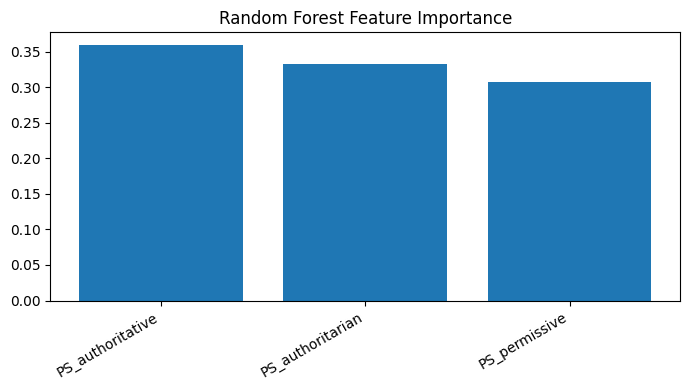

In [29]:
plt.figure(figsize=(7, 4))
plt.bar(rf_importance["Feature"], rf_importance["Importance"])
plt.xticks(rotation=30, ha="right")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

In [30]:
if not xgb_available:
    print("XGBoost not installed, skipping...")
else:
    print("Running XGBoost...")

    xgb_reg = XGBRegressor(
        n_estimators=300,
        max_depth=3,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    )

    xgb_reg.fit(X_train, y_train)
    xgb_pred = xgb_reg.predict(X_test)

    xgb_metrics = pd.DataFrame({
        "Model": ["XGBRegressor"],
        "R2": [r2_score(y_test, xgb_pred)],
        "RMSE": [mean_squared_error(y_test, xgb_pred, squared=False)]
    })

    display(xgb_metrics)

    xgb_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": xgb_reg.feature_importances_
    }).sort_values("Importance", ascending=False)

    display(xgb_importance)

Running XGBoost...


,Model,R2,RMSE
0,XGBRegressor,-0.159243,4.110241


,Feature,Importance
1,PS_authoritarian,0.349557
2,PS_permissive,0.337793
0,PS_authoritative,0.312650


In [31]:
lasso = LassoCV(cv=5, random_state=42).fit(X, y)
ridge = RidgeCV(cv=5).fit(X, y)

pd.DataFrame({
    "Feature": X.columns,
    "Lasso_coef": lasso.coef_,
    "Ridge_coef": ridge.coef_
})

,Feature,Lasso_coef,Ridge_coef
0,PS_authoritative,0.091732,0.091823
1,PS_authoritarian,0.227866,0.228560
2,PS_permissive,-0.566298,-0.568774


In [32]:
analysis_df["closeness_high"] = (analysis_df["PCR_closeness"] > analysis_df["PCR_closeness"].median()).astype(int)

Xc = analysis_df[["PS_authoritative", "PS_authoritarian", "PS_permissive"]]
yc = analysis_df["closeness_high"]

Xc_train, Xc_test, yc_train, yc_test = train_test_split(Xc, yc, test_size=0.2, random_state=42, stratify=yc)

logit_model = LogisticRegression()
logit_model.fit(Xc_train, yc_train)
logit_pred = logit_model.predict(Xc_test)

rf_clf = RandomForestClassifier(random_state=42, n_estimators=300)
rf_clf.fit(Xc_train, yc_train)
rf_clf_pred = rf_clf.predict(Xc_test)

clf_results = pd.DataFrame({
    "Model": ["LogisticRegression", "RandomForestClassifier"],
    "Accuracy": [
        accuracy_score(yc_test, logit_pred),
        accuracy_score(yc_test, rf_clf_pred)
    ]
})

clf_results

,Model,Accuracy
0,LogisticRegression,0.490196
1,RandomForestClassifier,0.490196


In [33]:
print("Logistic Regression")
print(classification_report(yc_test, logit_pred))

print("Random Forest Classifier")
print(classification_report(yc_test, rf_clf_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.49      0.41      0.45        51
           1       0.49      0.57      0.53        51

    accuracy                           0.49       102
   macro avg       0.49      0.49      0.49       102
weighted avg       0.49      0.49      0.49       102

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.49      0.47      0.48        51
           1       0.49      0.51      0.50        51

    accuracy                           0.49       102
   macro avg       0.49      0.49      0.49       102
weighted avg       0.49      0.49      0.49       102



In [34]:
rf_clf_importance = pd.DataFrame({
    "Feature": Xc.columns,
    "Importance": rf_clf.feature_importances_
}).sort_values("Importance", ascending=False)

rf_clf_importance

,Feature,Importance
1,PS_authoritarian,0.340958
0,PS_authoritative,0.334588
2,PS_permissive,0.324454


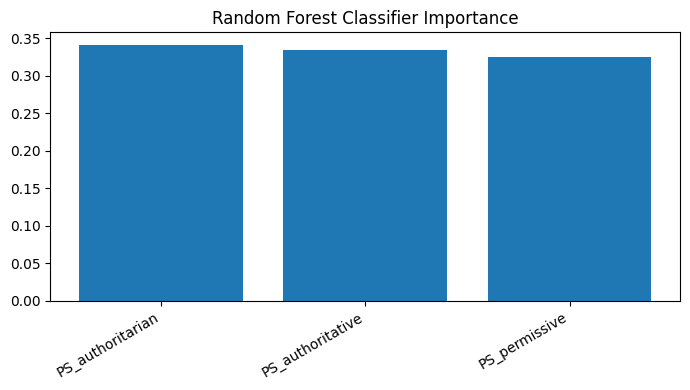

In [35]:
plt.figure(figsize=(7, 4))
plt.bar(rf_clf_importance["Feature"], rf_clf_importance["Importance"])
plt.xticks(rotation=30, ha="right")
plt.title("Random Forest Classifier Importance")
plt.tight_layout()
plt.show()

In [36]:
summary_table = pd.DataFrame({
    "Analysis": [
        "Cronbach alpha",
        "PCA",
        "Correlation",
        "Multiple regression",
        "Standardized regression",
        "Mediation",
        "Random forest regression",
        "Classification"
    ],
    "Purpose": [
        "Check reliability",
        "Extract factor structure",
        "Explore pairwise associations",
        "Estimate relationships between PS and PCR",
        "Compare relative strength",
        "Test indirect pathway",
        "Assess predictive importance",
        "Predict high vs low closeness"
    ]
})

summary_table

,Analysis,Purpose
0,Cronbach alpha,Check reliability
1,PCA,Extract factor structure
2,Correlation,Explore pairwise associations
3,Multiple regression,Estimate relationships between PS and PCR
4,Standardized regression,Compare relative strength
5,Mediation,Test indirect pathway
6,Random forest regression,Assess predictive importance
7,Classification,Predict high vs low closeness


In [44]:
ps_var.to_csv("ps_pca_variance.csv")
ps_loadings.to_csv("ps_pca_loadings.csv")

pcr_var.to_csv("pcr_pca_variance.csv")
pcr_loadings.to_csv("pcr_pca_loadings.csv")

corr_mat.to_csv("correlation_matrix.csv")
ols_results.to_csv("regression_results.csv", index=False)
std_results.to_csv("standardized_regression_results.csv", index=False)
rf_importance.to_csv("rf_regressor_importance.csv", index=False)
rf_clf_importance.to_csv("rf_classifier_importance.csv", index=False)

analysis_df.to_csv("analysis_dataset_with_factors.csv", index=False)